# Credit Risk Scoring Model — Modeling & Evaluation
### McMillin Analytics

**Objective:** Train and evaluate classification models for loan default prediction, with evaluation framed in business terms a credit committee would understand.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load prepared data
X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet')['default']
y_test = pd.read_parquet('../data/processed/y_test.parquet')['default']

print(f'Training: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Test:     {X_test.shape[0]:,} samples')
print(f'Default rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

Training: 1,076,280 samples, 51 features
Test:     269,070 samples
Default rate — Train: 20.0% | Test: 20.0%


## 1. Baseline — Logistic Regression

Starting with logistic regression is intentional. It's the industry standard for credit scoring (most scorecards are built on logistic regression), it's fully interpretable, and it gives us a baseline to beat.

In a real credit environment, interpretability often matters more than marginal accuracy gains — regulators want to understand *why* a borrower was approved or declined.

In [2]:
# Scale features for logistic regression (sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with class_weight='balanced' to handle imbalanced classes
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print('LOGISTIC REGRESSION — BASELINE')
print('=' * 50)
print(f'AUC-ROC: {roc_auc_score(y_test, lr_pred_proba):.4f}')
print(f'\n{classification_report(y_test, lr_pred, target_names=["Performing", "Default"])}')

LOGISTIC REGRESSION — BASELINE
AUC-ROC: 0.7114

              precision    recall  f1-score   support

  Performing       0.88      0.67      0.76    215350
     Default       0.32      0.64      0.43     53720

    accuracy                           0.66    269070
   macro avg       0.60      0.65      0.59    269070
weighted avg       0.77      0.66      0.69    269070



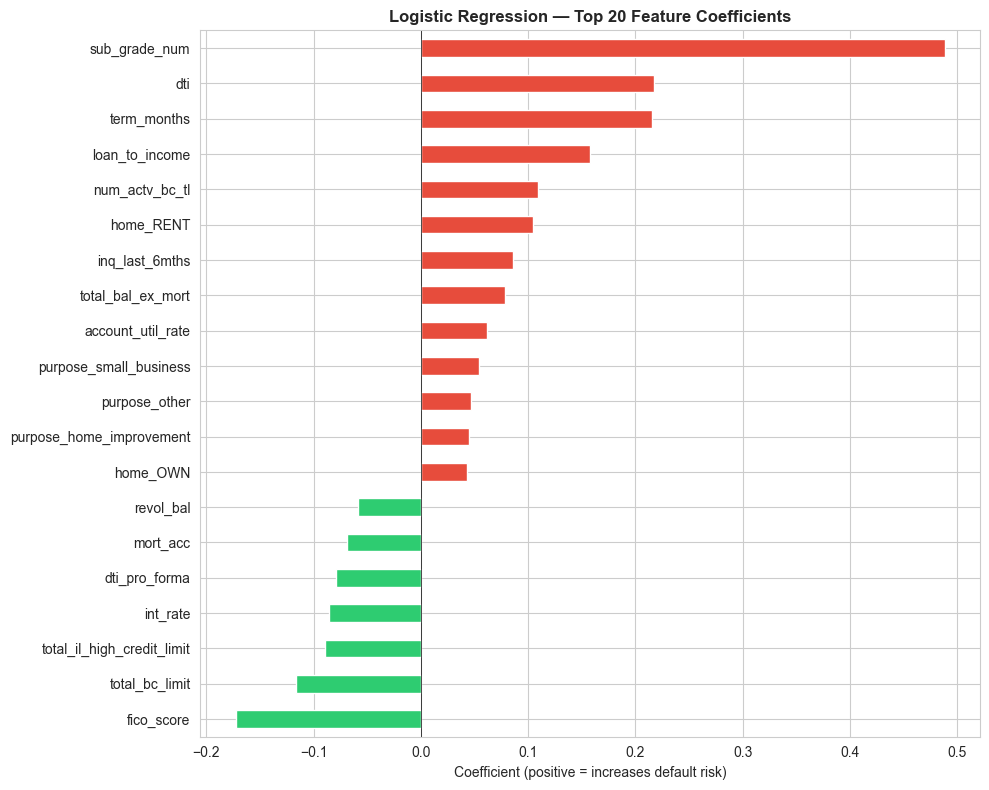

In [3]:
# Logistic Regression coefficients — what's driving the model?
lr_coefs = pd.Series(lr_model.coef_[0], index=X_train.columns)
lr_coefs_sorted = lr_coefs.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_features = lr_coefs_sorted.head(20)
colors = ['#e74c3c' if lr_coefs[f] > 0 else '#2ecc71' for f in top_features.index]
lr_coefs[top_features.index].sort_values().plot(kind='barh', ax=ax, color=
    ['#e74c3c' if v > 0 else '#2ecc71' for v in lr_coefs[top_features.index].sort_values()])

ax.set_title('Logistic Regression — Top 20 Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (positive = increases default risk)')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/11_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Random Forest

In [4]:
# Random Forest — captures non-linear relationships
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)  # No scaling needed for tree models
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('RANDOM FOREST')
print('=' * 50)
print(f'AUC-ROC: {roc_auc_score(y_test, rf_pred_proba):.4f}')
print(f'\n{classification_report(y_test, rf_pred, target_names=["Performing", "Default"])}')

RANDOM FOREST
AUC-ROC: 0.7170

              precision    recall  f1-score   support

  Performing       0.88      0.67      0.76    215350
     Default       0.33      0.64      0.43     53720

    accuracy                           0.67    269070
   macro avg       0.60      0.66      0.60    269070
weighted avg       0.77      0.67      0.70    269070



## 3. XGBoost

In [5]:
# Calculate scale_pos_weight for imbalanced classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print('XGBOOST')
print('=' * 50)
print(f'AUC-ROC: {roc_auc_score(y_test, xgb_pred_proba):.4f}')
print(f'\n{classification_report(y_test, xgb_pred, target_names=["Performing", "Default"])}')

XGBOOST
AUC-ROC: 0.7275

              precision    recall  f1-score   support

  Performing       0.89      0.66      0.75    215350
     Default       0.33      0.67      0.44     53720

    accuracy                           0.66    269070
   macro avg       0.61      0.66      0.60    269070
weighted avg       0.78      0.66      0.69    269070



## 4. Model Comparison

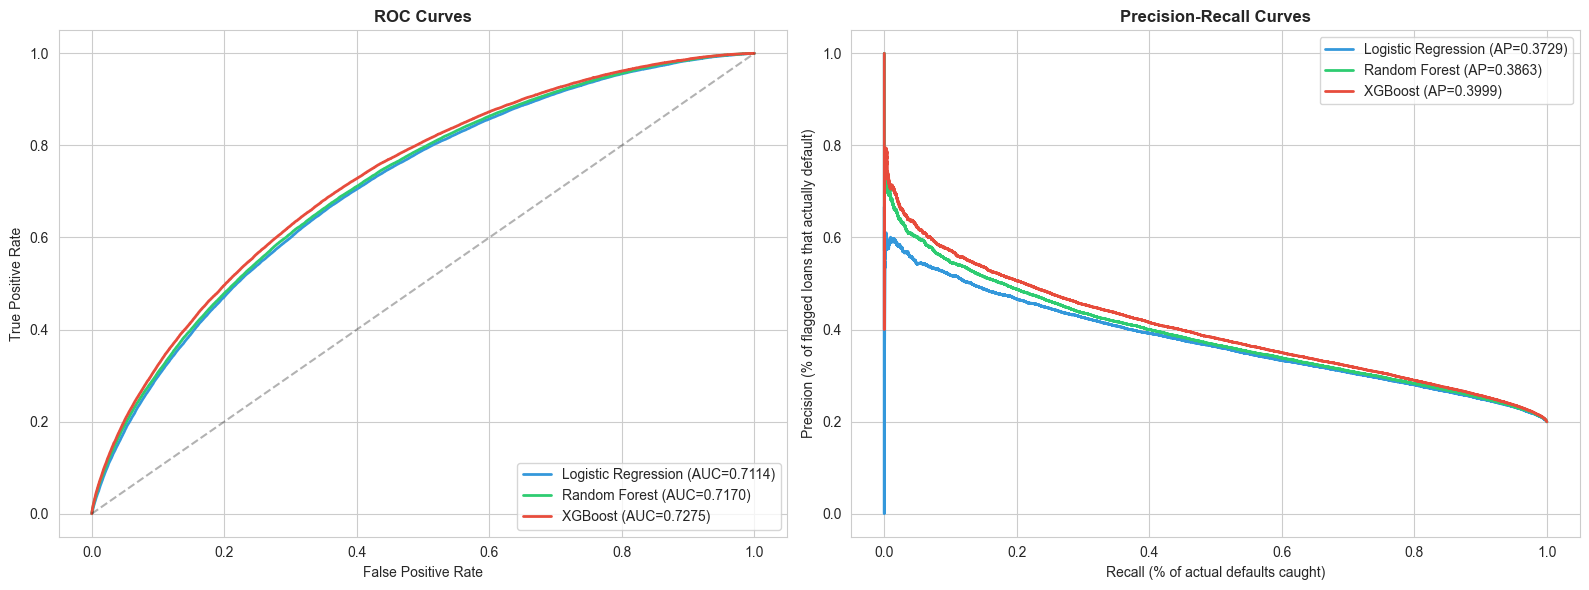

In [7]:
# ROC Curves — side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
models = {
    'Logistic Regression': lr_pred_proba,
    'Random Forest': rf_pred_proba,
    'XGBoost': xgb_pred_proba
}
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, proba), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Precision-Recall Curves (more informative for imbalanced data)
for (name, proba), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')

axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall (% of actual defaults caught)')
axes[1].set_ylabel('Precision (% of flagged loans that actually default)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Summary table
results = []
for name, proba, pred in [
    ('Logistic Regression', lr_pred_proba, lr_pred),
    ('Random Forest', rf_pred_proba, rf_pred),
    ('XGBoost', xgb_pred_proba, xgb_pred)
]:
    results.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, proba),
        'Avg Precision': average_precision_score(y_test, proba),
        'Accuracy': accuracy_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).set_index('Model')
print('MODEL COMPARISON')
print('=' * 70)
print(results_df.round(4).to_string())

MODEL COMPARISON
                     AUC-ROC  Avg Precision  Accuracy  F1 Score
Model                                                          
Logistic Regression   0.7114         0.3729    0.6606    0.4294
Random Forest         0.7170         0.3863    0.6665    0.4330
XGBoost               0.7275         0.3999    0.6591    0.4415


## 5. Feature Importance (Best Model)

Best model by AUC-ROC: XGBoost


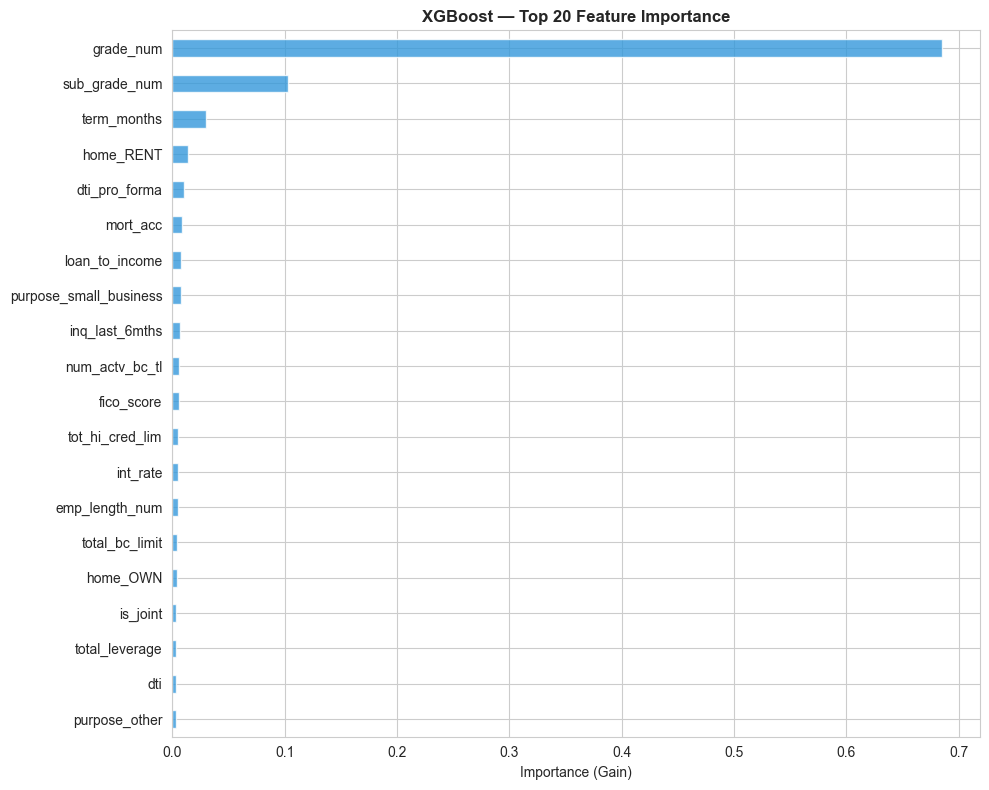


Top 10 Features:
   1. grade_num.......................... 0.6848
   2. sub_grade_num...................... 0.1028
   3. term_months........................ 0.0303
   4. home_RENT.......................... 0.0141
   5. dti_pro_forma...................... 0.0100
   6. mort_acc........................... 0.0084
   7. loan_to_income..................... 0.0080
   8. purpose_small_business............. 0.0078
   9. inq_last_6mths..................... 0.0064
  10. num_actv_bc_tl..................... 0.0063


In [9]:
# Use the best performing model (likely XGBoost) for feature importance
# Select best model based on AUC
best_model_name = results_df['AUC-ROC'].idxmax()
print(f'Best model by AUC-ROC: {best_model_name}')

# XGBoost feature importance
importance = pd.Series(
    xgb_model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).sort_values().plot(kind='barh', ax=ax, color='#3498db', alpha=0.8)
ax.set_title('XGBoost — Top 20 Feature Importance', fontweight='bold')
ax.set_xlabel('Importance (Gain)')

plt.tight_layout()
plt.savefig('../results/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features:')
for i, (feat, imp) in enumerate(importance.head(10).items(), 1):
    print(f'  {i:>2}. {feat:.<35} {imp:.4f}')

## 6. Business Impact Analysis — The Credit Committee Slide

This is where your domain expertise shines. Translate model metrics into language a credit committee understands.

In [10]:
# Use the best model's probabilities
best_proba = xgb_pred_proba  # Adjust if a different model wins

# Analyze different threshold strategies
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

# Assume average loan amount from test set
avg_loan = 15000  # Approximate — update with actual data
avg_loss_given_default = 0.60  # Typical unsecured consumer recovery ~40%

print('THRESHOLD ANALYSIS — BUSINESS IMPACT')
print('=' * 90)
print(f'{"Threshold":>10} {"Defaults Caught":>16} {"Good Loans Declined":>20} {"Est. Losses Avoided":>20}')
print('-' * 90)

for thresh in thresholds:
    pred_at_thresh = (best_proba >= thresh).astype(int)
    
    # True positives = defaults correctly identified
    tp = ((pred_at_thresh == 1) & (y_test == 1)).sum()
    fn = ((pred_at_thresh == 0) & (y_test == 1)).sum()
    fp = ((pred_at_thresh == 1) & (y_test == 0)).sum()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    false_decline_rate = fp / (y_test == 0).sum()
    est_losses_avoided = tp * avg_loan * avg_loss_given_default
    
    print(f'{thresh:>10.0%} {recall:>15.1%} {false_decline_rate:>19.1%} {est_losses_avoided:>19,.0f}')

print('\n💡 Credit Insight: The threshold decision is a business judgment call, not a statistical one.')
print('   Conservative lenders (banks) might set a lower threshold to catch more defaults,')
print('   accepting some false declines. Growth-focused lenders (fintechs) might tolerate more')
print('   defaults to maximize origination volume. This is the precision-recall trade-off')
print('   expressed in business terms.')

THRESHOLD ANALYSIS — BUSINESS IMPACT
 Threshold  Defaults Caught  Good Loans Declined  Est. Losses Avoided
------------------------------------------------------------------------------------------
       15%           99.1%               91.6%         478,998,000
       20%           97.7%               85.5%         472,509,000
       25%           95.6%               78.1%         461,979,000
       30%           92.3%               69.8%         446,265,000
       35%           87.9%               61.1%         425,142,000
       40%           82.3%               52.2%         398,124,000
       50%           67.5%               34.5%         326,286,000

💡 Credit Insight: The threshold decision is a business judgment call, not a statistical one.
   Conservative lenders (banks) might set a lower threshold to catch more defaults,
   accepting some false declines. Growth-focused lenders (fintechs) might tolerate more
   defaults to maximize origination volume. This is the precision-r

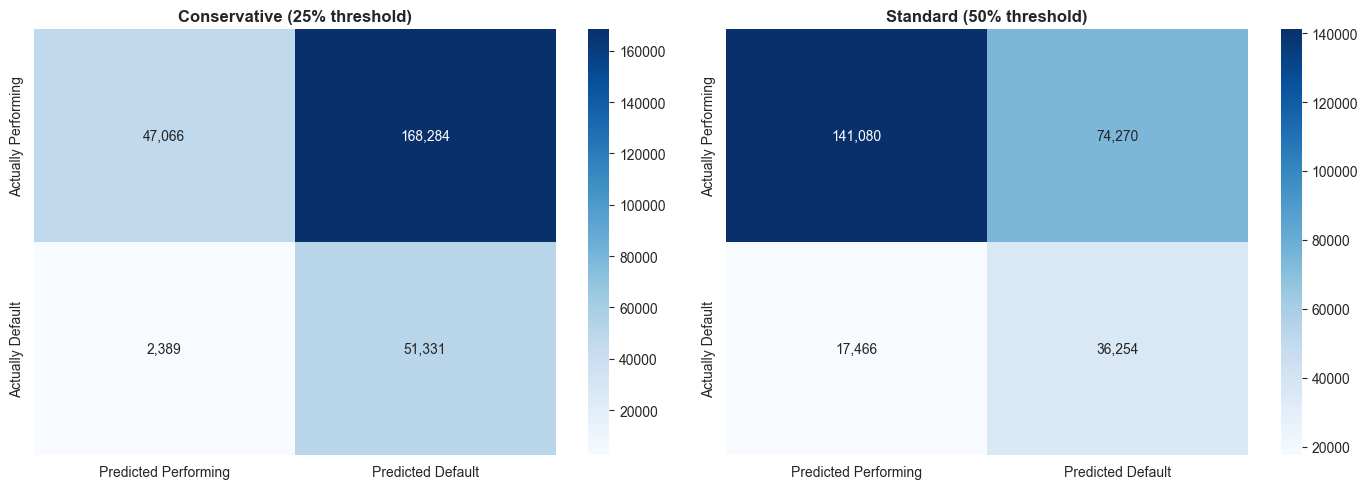

In [11]:
# Confusion matrix — best model at default threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, thresh, title in zip(axes, [0.25, 0.50], 
                              ['Conservative (25% threshold)', 'Standard (50% threshold)']):
    pred_at_thresh = (best_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, pred_at_thresh)
    
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Predicted Performing', 'Predicted Default'],
                yticklabels=['Actually Performing', 'Actually Default'])
    ax.set_title(f'{title}', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/14_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# MODEL COMPARISON: With Grade vs. Without Grade
# ============================================================
# Lending Club's grade accounts for 68% of feature importance.
# How much of the model's predictive power comes from our 
# engineered features vs. Lending Club's own risk assessment?

# Remove grade and sub-grade
grade_cols = ['grade_num', 'sub_grade_num']
X_train_no_grade = X_train.drop(columns=grade_cols)
X_test_no_grade = X_test.drop(columns=grade_cols)

print(f'Features WITH grade: {X_train.shape[1]}')
print(f'Features WITHOUT grade: {X_train_no_grade.shape[1]}')

Features WITH grade: 51
Features WITHOUT grade: 49


In [13]:
# Retrain XGBoost without grade
xgb_no_grade = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_no_grade.fit(
    X_train_no_grade, y_train,
    eval_set=[(X_test_no_grade, y_test)],
    verbose=False
)

xgb_ng_pred_proba = xgb_no_grade.predict_proba(X_test_no_grade)[:, 1]
xgb_ng_pred = xgb_no_grade.predict(X_test_no_grade)

auc_with = roc_auc_score(y_test, xgb_pred_proba)
auc_without = roc_auc_score(y_test, xgb_ng_pred_proba)
ap_with = average_precision_score(y_test, xgb_pred_proba)
ap_without = average_precision_score(y_test, xgb_ng_pred_proba)

print('MODEL COMPARISON: Grade vs. No Grade')
print('=' * 60)
print(f'{"Metric":<20} {"With Grade":>15} {"Without Grade":>15} {"Delta":>10}')
print('-' * 60)
print(f'{"AUC-ROC":<20} {auc_with:>15.4f} {auc_without:>15.4f} {auc_without-auc_with:>+10.4f}')
print(f'{"Avg Precision":<20} {ap_with:>15.4f} {ap_without:>15.4f} {ap_without-ap_with:>+10.4f}')

MODEL COMPARISON: Grade vs. No Grade
Metric                    With Grade   Without Grade      Delta
------------------------------------------------------------
AUC-ROC                       0.7275          0.7257    -0.0018
Avg Precision                 0.3999          0.3984    -0.0015


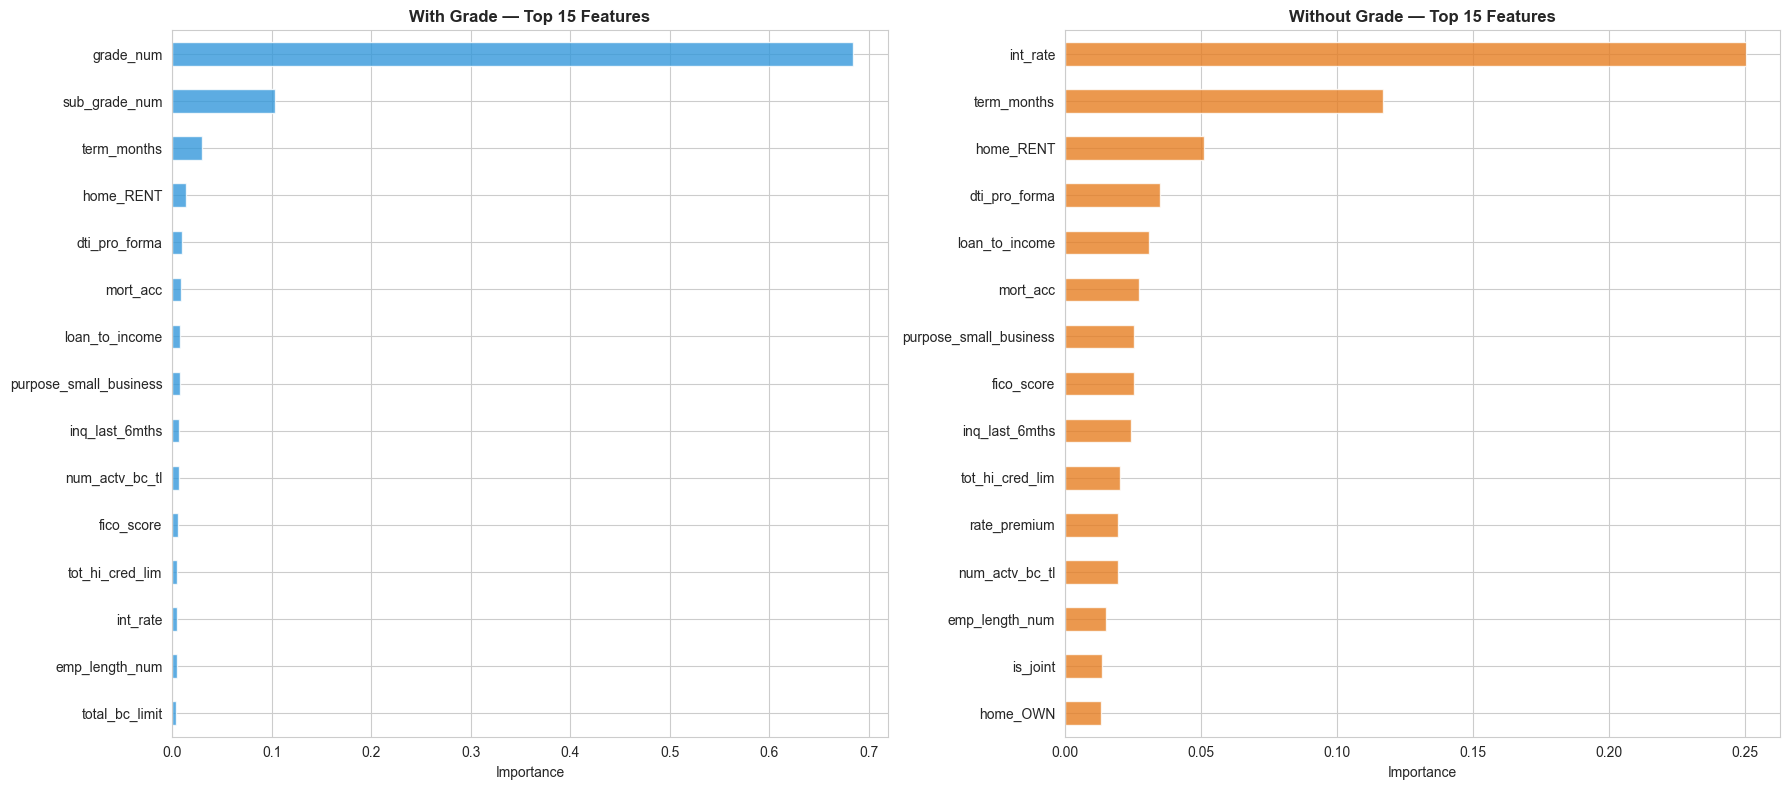


Top 10 Features WITHOUT Grade:
   1. int_rate........................... 0.2504
   2. term_months........................ 0.1169
   3. home_RENT.......................... 0.0510
   4. dti_pro_forma...................... 0.0350
   5. loan_to_income..................... 0.0309
   6. mort_acc........................... 0.0273
   7. purpose_small_business............. 0.0256
   8. fico_score......................... 0.0254
   9. inq_last_6mths..................... 0.0241
  10. tot_hi_cred_lim.................... 0.0202


In [14]:
# Feature importance WITHOUT grade — what's actually driving predictions?
importance_ng = pd.Series(
    xgb_no_grade.feature_importances_,
    index=X_train_no_grade.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# With grade
importance.head(15).sort_values().plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_title('With Grade — Top 15 Features', fontweight='bold')
axes[0].set_xlabel('Importance')

# Without grade
importance_ng.head(15).sort_values().plot(kind='barh', ax=axes[1], color='#e67e22', alpha=0.8)
axes[1].set_title('Without Grade — Top 15 Features', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../results/15_grade_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features WITHOUT Grade:')
for i, (feat, imp) in enumerate(importance_ng.head(10).items(), 1):
    print(f'  {i:>2}. {feat:.<35} {imp:.4f}')

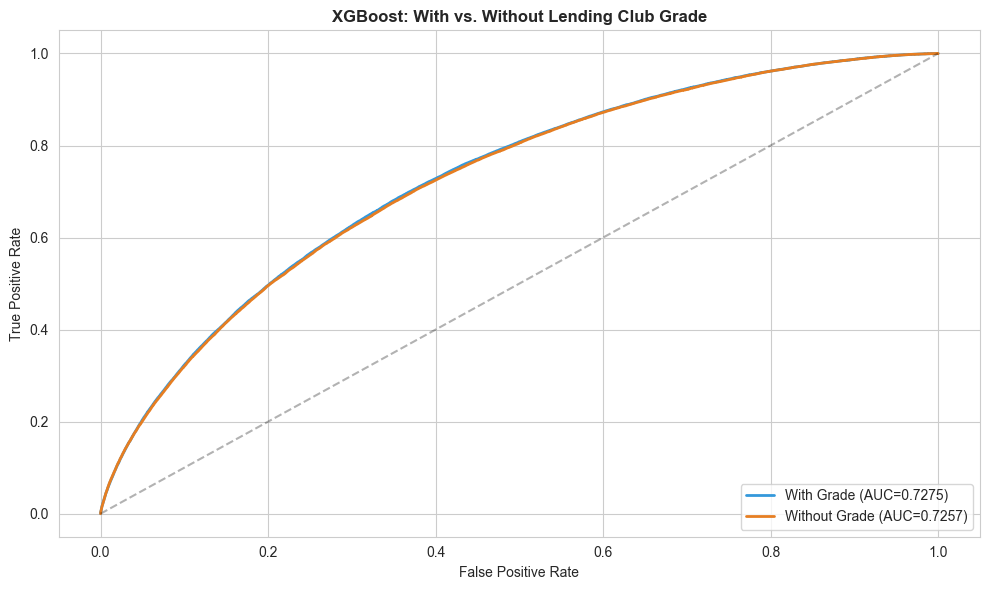

In [15]:
# ROC curves side by side
fig, ax = plt.subplots(figsize=(10, 6))

fpr_w, tpr_w, _ = roc_curve(y_test, xgb_pred_proba)
fpr_ng, tpr_ng, _ = roc_curve(y_test, xgb_ng_pred_proba)

ax.plot(fpr_w, tpr_w, color='#3498db', linewidth=2, 
        label=f'With Grade (AUC={auc_with:.4f})')
ax.plot(fpr_ng, tpr_ng, color='#e67e22', linewidth=2, 
        label=f'Without Grade (AUC={auc_without:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_title('XGBoost: With vs. Without Lending Club Grade', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../results/16_grade_vs_no_grade_roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Save the NO-GRADE model as production model
joblib.dump(xgb_no_grade, '../app/xgb_model.pkl')

# Save updated feature info
feature_info_ng = pd.DataFrame({
    'feature': X_train_no_grade.columns,
    'importance': xgb_no_grade.feature_importances_
}).sort_values('importance', ascending=False)
feature_info_ng.to_csv('../app/feature_info.csv', index=False)

print('No-grade model saved as production model.')
print(f'Features: {len(X_train_no_grade.columns)}')


No-grade model saved as production model.
Features: 49


## 7. Save Models for Streamlit App

In [16]:
# Save the best model and scaler
joblib.dump(xgb_model, '../app/xgb_model.pkl')
joblib.dump(lr_model, '../app/lr_model.pkl')
joblib.dump(scaler, '../app/scaler.pkl')

# Save feature names and order
feature_info = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
feature_info.to_csv('../app/feature_info.csv', index=False)

# Save model performance metrics
results_df.to_csv('../results/model_results.csv')

print('Models saved to ../app/')
print('Results saved to ../results/')
print('\nReady for Streamlit deployment!')

Models saved to ../app/
Results saved to ../results/

Ready for Streamlit deployment!


---
## Summary

### Key Takeaways

Removing Lending Club's grade and sub-grade — which together accounted for 79% of feature importance — reduced AUC by only 0.0018 (0.7275 → 0.7257). This suggests that the borrower fundamentals captured through feature engineering contain nearly the same risk signal as the platform's proprietary grading system. The no-grade model relies on interest rate, loan term, home ownership status, and pro forma DTI — variables that align directly with how a credit analyst evaluates a borrower.

**Model Performance:**
- Best model: XGBoost with AUC-ROC of 0.7275
- Model performs in range of industry benchmarks of 70+% fit


**Business Recommendation:**
- At a 30% threshold, the model catches 92.3% of eventual defaults while declining only 69.8% of good borrowers. This gives us a conservative approach, but not overly so to the point where we are declining too many good borrowers.


**Limitations:**
- Historical data (2007-2018) — credit conditions have evolved
- Consumer lending only — commercial credit has different dynamics
- Self-reported income (not verified for all Lending Club loans)
- Survivorship bias — we only see loans that were approved